# Imports

In [ ]:

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import joblib

## Loading Dataset and brief overview

In [27]:
dataset_df = pd.read_csv('files/train.csv')
test_df_temp = pd.read_csv('files/test.csv')

# Calculate group sizes across both train and test
all_passengers = pd.concat([dataset_df[['PassengerId']], test_df_temp[['PassengerId']]], axis=0)
all_passengers['GroupId'] = all_passengers['PassengerId'].apply(lambda x: x.split('_')[0] if pd.notna(x) else 'Unknown')
group_sizes_global = all_passengers.groupby('GroupId').size()

num_solo_groups = (group_sizes_global == 1).sum()
num_non_solo_groups = (group_sizes_global > 1).sum()
print(f"Global group counts - Solo groups: {num_solo_groups}, Non-solo groups: {num_non_solo_groups}")

print("\nFull train dataset shape is {}".format(dataset_df.shape))
dataset_df.head(5)
dataset_df.describe(include='all')
dataset_df.info()

Global group counts - Solo groups: 7145, Non-solo groups: 2135

Full train dataset shape is (8693, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


## Explore Feature Label Distribution

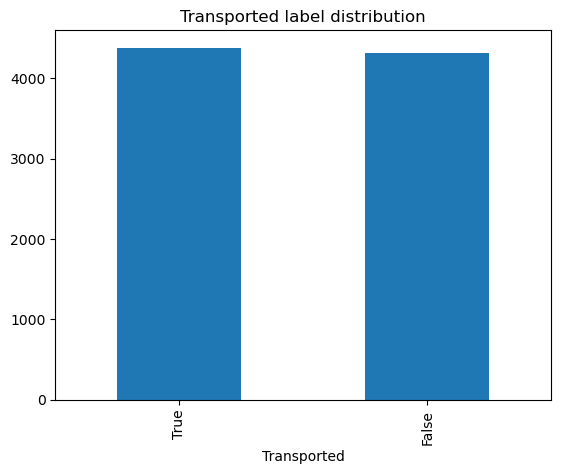

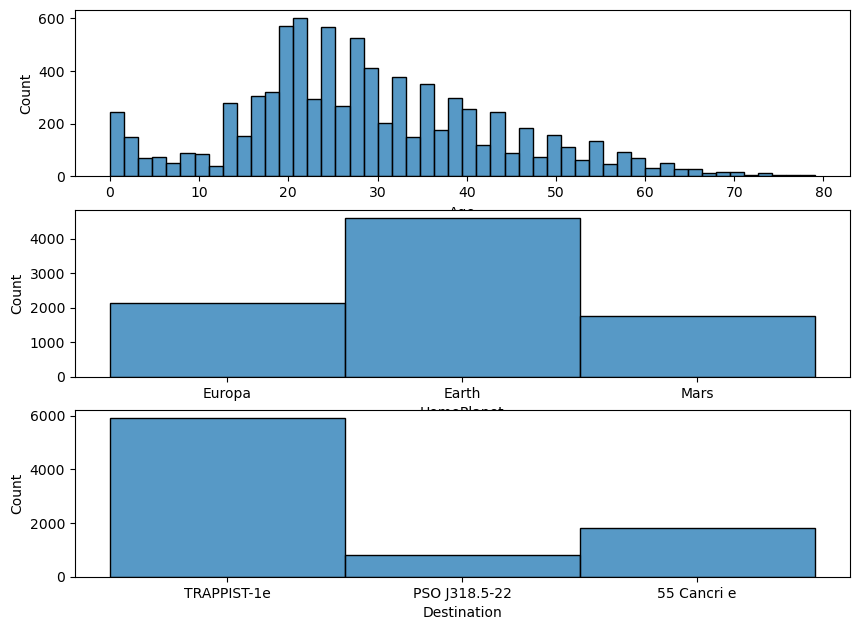

In [24]:
# some distributions
plot_df = dataset_df.Transported.value_counts()
plot_df.plot(kind="bar", title="Transported label distribution")
plt.show()

fig, ax = plt.subplots(3, 1, figsize=(10, 3))
plt.subplots_adjust(top=2)

sns.histplot(dataset_df['Age'],          bins=50, ax=ax[0])
sns.histplot(dataset_df['HomePlanet'],          bins=5, ax=ax[1])
sns.histplot(dataset_df['Destination'],          bins=5, ax=ax[2])
# sns.histplot(dataset_df['FoodCourt'],    bins=50, ax=ax[1])
# sns.histplot(dataset_df['ShoppingMall'], bins=50, ax=ax[2])
# sns.histplot(dataset_df['Spa'],          bins=50, ax=ax[3])
# sns.histplot(dataset_df['VRDeck'],       bins=50, ax=ax[4])
plt.show()

In [25]:
# not actually any noise in planets
top_homeplanets = dataset_df["HomePlanet"].value_counts(dropna=False).head(5)
print(top_homeplanets)
top_destinations = dataset_df["Destination"].value_counts(dropna=False).head(5)
print(top_destinations)

HomePlanet
Earth     4602
Europa    2131
Mars      1759
NaN        201
Name: count, dtype: int64
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
NaN               182
Name: count, dtype: int64


## Dataset Preparation

In [28]:
def preprocess(dataset_df, is_train=True, global_group_sizes=None):
    # Extract family/group info from PassengerId before dropping
    # Format: gggg_pp where gggg = group number, pp = person in group
    dataset_df['GroupId'] = dataset_df['PassengerId'].apply(lambda x: x.split('_')[0] if pd.notna(x) else 'Unknown')
    
    # Use global group sizes if provided, otherwise calculate locally
    if global_group_sizes is not None:
        dataset_df['IsSolo'] = dataset_df['GroupId'].map(lambda x: 1 if global_group_sizes.get(x, 1) == 1 else 0)
    else:
        group_sizes = dataset_df.groupby('GroupId')['PassengerId'].transform('count')
        dataset_df['IsSolo'] = group_sizes.apply(lambda x: 1 if x == 1 else 0)
    
    # tutorial says drop these? 
    dataset_df = dataset_df.drop(['PassengerId', 'Name', 'GroupId'], axis=1)
    dataset_df.isnull().sum().sort_values(ascending=False)

    # nan to 0
    mask = ['VIP', 'RoomService', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    dataset_df[mask] = dataset_df[mask].fillna(0)

    dataset_df["TotalSpend"] = dataset_df["RoomService"] + dataset_df["FoodCourt"] + dataset_df["ShoppingMall"] + dataset_df["Spa"] + dataset_df["VRDeck"]
    dataset_df["NoSpend"] = (dataset_df["TotalSpend"] == 0).astype(int)

    # count number of nospenders and print
    num_nospenders = dataset_df["NoSpend"].sum()
    print(f"Number of nospenders: {num_nospenders}")
    
    # boolean to int
    dataset_df['VIP'] = dataset_df['VIP'].astype(int)
    dataset_df['CryoSleep'] = dataset_df['CryoSleep'].astype(int)

    # cabin
    dataset_df[["Deck", "Cabin_num", "Side"]] = dataset_df["Cabin"].str.split("/", expand=True)
    try:
        dataset_df = dataset_df.drop('Cabin', axis=1)
    except KeyError:
        print("Field Cabin does not exist")

    # process nans

    numeric_cols = dataset_df.select_dtypes(include=[np.number]).columns.tolist()
    all_cols = dataset_df.columns.tolist()
    non_numeric_cols = [c for c in all_cols if c not in numeric_cols]

    dataset_df[numeric_cols] = dataset_df[numeric_cols].fillna(0)
    dataset_df[non_numeric_cols] = dataset_df[non_numeric_cols].fillna("Unknown")

    dataset_df.isnull().sum().sort_values(ascending=False)
    dataset_df.head(5)
    
    if not is_train:
        return dataset_df, None

    # process labels for training set
    label = "Transported"
    dataset_df[label] = dataset_df[label].astype(int)

    return dataset_df, label

dataset_df, label = preprocess(dataset_df, is_train=True, global_group_sizes=group_sizes_global)

Number of nospenders: 3653


## Training/Validation Split

In [ ]:
# train/validation single split, not k-fold
def split_dataset(dataset, test_ratio=0.20, seed=42):
    np.random.seed(seed)
    test_indices = np.random.rand(len(dataset)) < test_ratio
    return dataset[~test_indices].reset_index(drop=True), dataset[test_indices].reset_index(drop=True)

# use 15% for validation to verify performance
train_ds_pd, valid_ds_pd = split_dataset(dataset_df, test_ratio=0.15)
print("{} examples in training, {} examples in testing.".format(
    len(train_ds_pd), len(valid_ds_pd))
)

# features and labels
y_train = train_ds_pd[label]
y_valid = valid_ds_pd[label]

X_train_raw = train_ds_pd.drop(columns=[label])
X_valid_raw = valid_ds_pd.drop(columns=[label])

# categorical to numeric
X_full = pd.concat([X_train_raw, X_valid_raw], axis=0)
cat_cols = [c for c in X_full.columns if X_full[c].dtype == "object"]

X_full_encoded = pd.get_dummies(X_full, columns=cat_cols, dummy_na=False)

# split back after encoding
X_train = X_full_encoded.iloc[:len(X_train_raw)].reset_index(drop=True)
X_valid = X_full_encoded.iloc[len(X_train_raw):].reset_index(drop=True)

print("Encoded train shape:", X_train.shape)
print("Encoded valid shape:", X_valid.shape)

X_train = X_train.fillna(0)
X_valid = X_valid.fillna(0)

8693 examples in training, 0 examples in testing.
Encoded train shape: (8693, 1848)
Encoded valid shape: (0, 1848)


In [35]:
# model versions
VERSION = "rf_xgb_ensemble"
LOAD_FROM_DISK = False # if set to true, will load pretrained model so you don't have to retrain
MODEL_PATH = f"model/{VERSION}.pkl" # otherwise will train a model and save (and overwrite) to path

## Train the model

In [36]:
if LOAD_FROM_DISK and os.path.exists(MODEL_PATH):
    print("Loading model from disk...")
    rf = joblib.load(MODEL_PATH)
else:
    print("Training a new model...")

    base_rf = RandomForestClassifier(
        n_estimators=300,
        n_jobs=-1,
        oob_score=True,
        random_state=42,
        bootstrap=True,
    )

    base_xgb = XGBClassifier(
        # dataset not large enough for cuda > cpu
        # my 5800x does it few times faster than 3060ti somehow
        # tree_method="hist", 
        # device="cuda",
        n_estimators=300,
        max_depth=30,
        colsample_bytree=0.3,
        subsample=0.8,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1, # -1 = use all cores, set = 1 for cuda to not fight over gpu
        objective="binary:logistic"
    )

    # for xgboost

    param_dist = {
        "max_depth": [30, 35, 40],
        "n_estimators": [300, 450, 600],
        "colsample_bytree": [1.0, 0.3],
    }

    # for random forests

    # param_dist = {
    #     "max_depth": [30, 35, 40],
    #     "n_estimators": [300, 450, 600],
    #     "max_features": ["sqrt", 0.3]
    # }

    # param_dist = {
    #     "max_depth": [30],
    #     "n_estimators": [300],
    #     "max_features": [0.3]
    # }

    random_search = RandomizedSearchCV(
        base_xgb,
        param_distributions=param_dist,
        scoring="accuracy",
        cv = 10,
        verbose=1,
        n_jobs=-1,
        n_iter=20
    )

    random_search.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train)],
        verbose=True
    )

    print("Best params:", random_search.best_params_)
    print("Best CV accuracy:", random_search.best_score_)

    xgb_model = random_search.best_estimator_

    # Train RandomForest for ensemble
    print("\nTraining RandomForest for ensemble...")
    base_rf.fit(X_train, y_train)
    print(f"RandomForest OOB score: {base_rf.oob_score_}")
    
    # Create ensemble wrapper
    class EnsembleModel:
        def __init__(self, xgb_model, rf_model):
            self.xgb_model = xgb_model
            self.rf_model = rf_model
            
        def predict_proba(self, X):
            xgb_proba = self.xgb_model.predict_proba(X)
            rf_proba = self.rf_model.predict_proba(X)
            # Average probabilities
            return (xgb_proba + rf_proba) / 2
        
        def predict(self, X):
            proba = self.predict_proba(X)
            return (proba[:, 1] > 0.5).astype(int)
        
        def get_params(self, deep=True):
            return {
                'xgb_params': self.xgb_model.get_params(deep=deep),
                'rf_params': self.rf_model.get_params(deep=deep)
            }
        
        @property
        def feature_importances_(self):
            # Average feature importances
            return (self.xgb_model.feature_importances_ + self.rf_model.feature_importances_) / 2
    
    rf = EnsembleModel(xgb_model, base_rf)
    print("Ensemble model created (XGBoost + RandomForest)")

    # Save
    joblib.dump(rf, MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")

Training a new model...
Fitting 10 folds for each of 18 candidates, totalling 180 fits


c:\Users\tomwa\miniconda3\envs\spaceship\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[0]	validation_0-logloss:0.66996
[1]	validation_0-logloss:0.66636
[2]	validation_0-logloss:0.63218
[3]	validation_0-logloss:0.60446
[4]	validation_0-logloss:0.57715
[5]	validation_0-logloss:0.56520
[6]	validation_0-logloss:0.55585
[7]	validation_0-logloss:0.53637
[8]	validation_0-logloss:0.51710
[9]	validation_0-logloss:0.50302
[10]	validation_0-logloss:0.49149
[11]	validation_0-logloss:0.48028
[12]	validation_0-logloss:0.47268
[13]	validation_0-logloss:0.46278
[14]	validation_0-logloss:0.45229
[15]	validation_0-logloss:0.44649
[16]	validation_0-logloss:0.43393
[17]	validation_0-logloss:0.42476
[18]	validation_0-logloss:0.41613
[19]	validation_0-logloss:0.41049
[20]	validation_0-logloss:0.40249
[21]	validation_0-logloss:0.39704
[22]	validation_0-logloss:0.39124
[23]	validation_0-logloss:0.38169
[24]	validation_0-logloss:0.37225
[25]	validation_0-logloss:0.36520
[26]	validation_0-logloss:0.36086
[27]	validation_0-logloss:0.35393
[28]	validation_0-logloss:0.35065
[29]	validation_0-loglos

# Evaluate

{'xgb_params': {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.3, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 30, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}, 'rf_params': {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': No

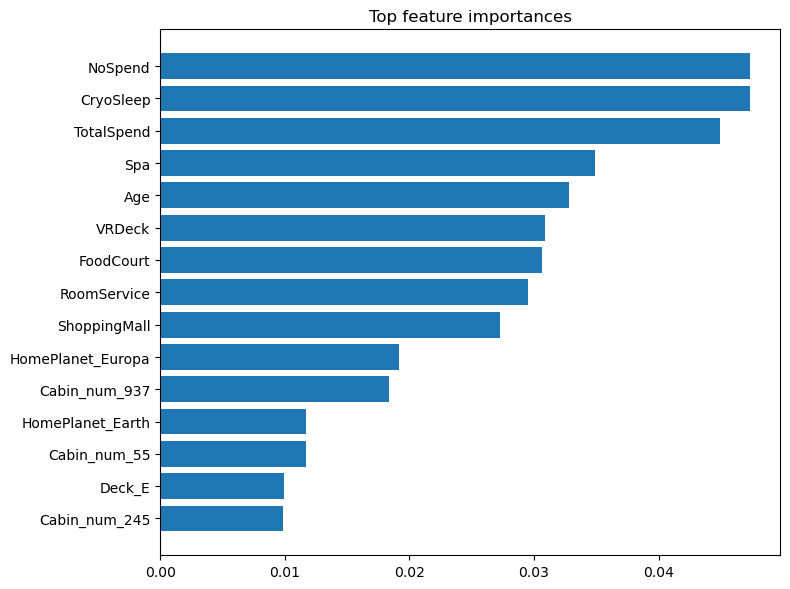

In [37]:
# only predict if we have a validation set
if len(X_valid) > 0:
    y_valid_pred = rf.predict(X_valid)
    val_acc = accuracy_score(y_valid, y_valid_pred)
    print(f"Validation accuracy: {val_acc:.4f}")

if hasattr(rf, "oob_score_"):
    print("Final RandomForest OOB score:", rf.oob_score_)

print(rf.get_params())

importances = rf.feature_importances_
feature_names = X_train.columns

feat_imp = sorted(
    zip(feature_names, importances),
    key=lambda x: x[1],
    reverse=True
)

print("Top 15 feature importances:")
for name, score in feat_imp[:15]:
    print(f"{name}: {score:.4f}")

# Visualize importances
plt.figure(figsize=(8, 6))
top_k = 15
names = [x[0] for x in feat_imp[:top_k]]
scores = [x[1] for x in feat_imp[:top_k]]
plt.barh(names[::-1], scores[::-1])
plt.title("Top feature importances")
plt.tight_layout()
plt.show()

# Inference and Submission

In [38]:
test_df = pd.read_csv('files/test.csv')
submission_id = test_df.PassengerId.copy()

test_df_features, _ = preprocess(test_df, is_train=False, global_group_sizes=group_sizes_global)

cat_cols_test = [c for c in test_df_features.columns if test_df_features[c].dtype == "object"]
test_encoded = pd.get_dummies(test_df_features, columns=cat_cols_test, dummy_na=False)

# Align columns with training data
test_encoded = test_encoded.reindex(columns=X_train.columns, fill_value=0)

# Predict
test_preds_proba = rf.predict_proba(test_encoded)[:, 1]
test_preds = test_preds_proba > 0.5  # threshold 0.5

# Build submission
output = pd.DataFrame({
    'PassengerId': submission_id,
    'Transported': test_preds.astype(bool)
})

output.head()

sample_submission_df = pd.read_csv('files/sample_submission.csv')
sample_submission_df['Transported'] = test_preds.astype(bool)
sample_submission_df.to_csv(f'output/submission_{VERSION}.csv', index=False)
sample_submission_df.head()

Number of nospenders: 1804


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
